In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm
from scipy.interpolate import make_smoothing_spline
from sklearn.metrics import r2_score

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

import imageio
import os
import shutil
import sys

PROJECT_ROOT = "../"
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.loaders import load_all_ploidy_liquid, load_all_ploidy, load_adaptive_stability_results, load_adaptive_stability_results_liquid, load_ensemble

In [2]:
stab = load_adaptive_stability_results()

In [3]:
### Error areas x ###
def return_stats(vec, interv):
    means =[]
    stds = []
    for i in range(len(interv)-1):
        provv = []
        for j in range(len(vec)):
            provv.append(np.where(np.logical_and(vec[j]>interv[i],vec[j]<=interv[i+1]))[0])
        provv = np.concatenate(provv)
        means.append(np.mean(provv))
        stds.append(np.std(provv))
    
    return np.array(means), np.array(stds)

def reconstruct_ymean(mm, space):
    x = []
    for i in range(int(max(mm))):
        p0 = np.where(mm<=i)[0][-1]
        p1 = np.where(mm>i)[0][0]
        slope = space/(mm[p1]-mm[p0])
        x.append(interv_0[p0]+slope*1)
    return np.array(x)

def running_slope(x, skip):
    vec = []
    for i in range(skip, len(x)-skip-1):
        vec.append((x[i+skip]-x[i])/skip)
    return np.array(vec)

### Error areas y ###
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = []
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = np.quantile(arr, 0.5)
            stds.append([np.quantile(arr, 0.159), np.quantile(arr, 0.841)]) # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds.append([np.nan, np.nan])
            
    return np.array(means), np.array(stds)

def plot_stats_elementwise(x, ax, label="", color="C0", lw=3, alpha=0.3):
    means, stds = stats_elementwise(x)
    
    ax.plot(np.arange(len(means)), means, color=color, lw=lw, label=label)
    ax.fill_between(np.arange(len(means)) ,stds[:,0], stds[:,1], color=color, alpha=alpha)

In [4]:
data_l = load_all_ploidy_liquid()
data_s = load_all_ploidy()

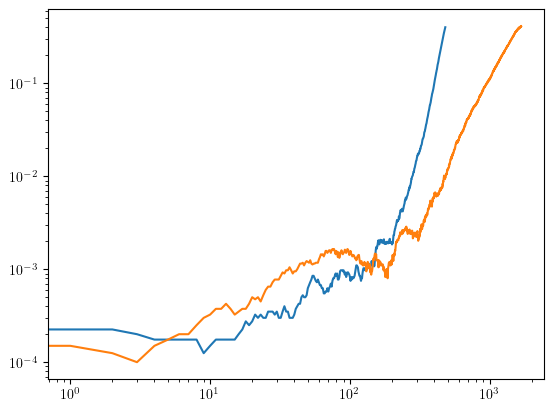

In [5]:
plt.plot(data_l['Diploid'][1][20]['tumor_density'])
plt.xscale("log")
plt.yscale("log")
plt.plot(data_s['Diploid'][1][20]['tumor_density'])
plt.xscale("log")
plt.yscale("log")

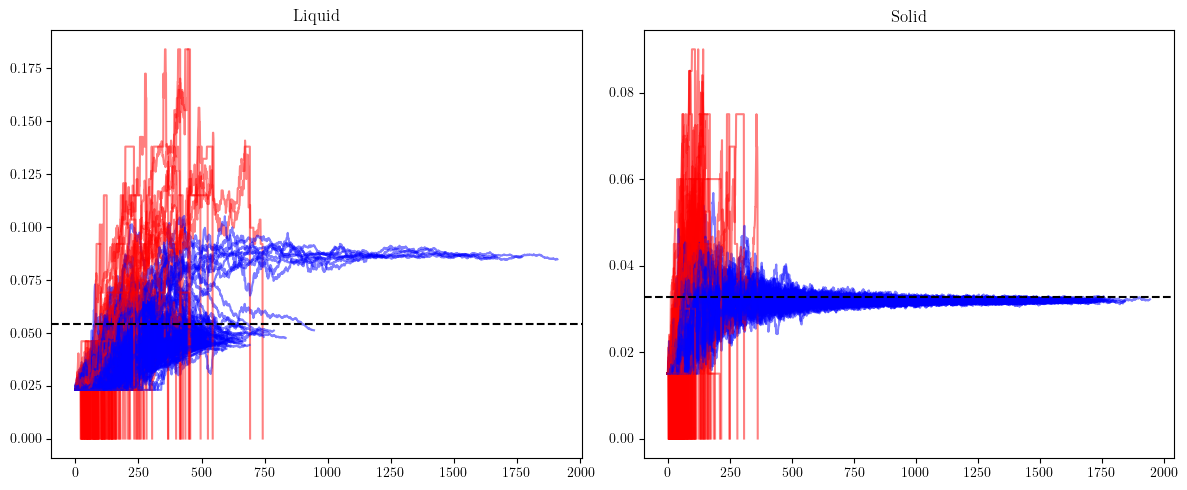

In [6]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

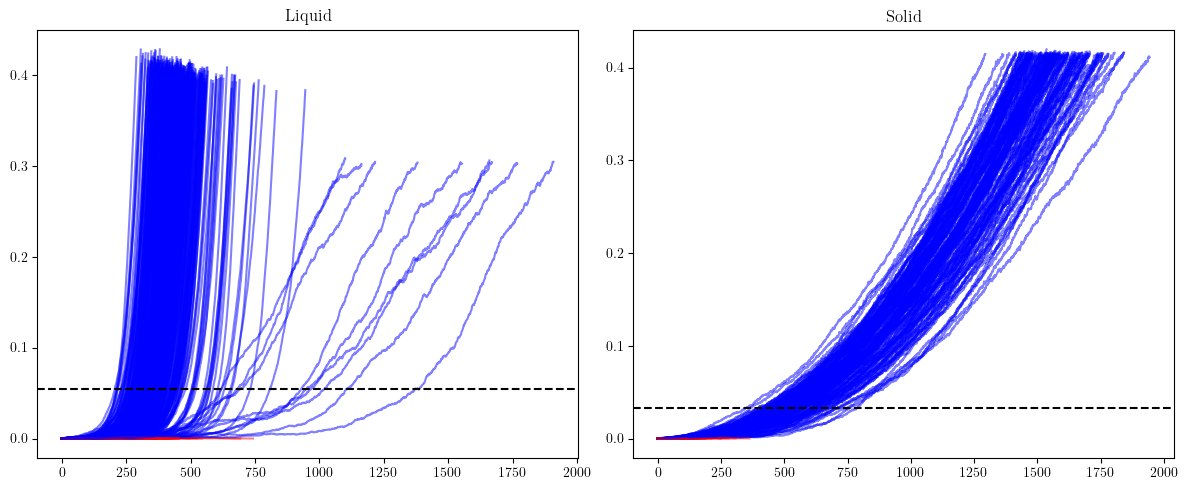

In [7]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

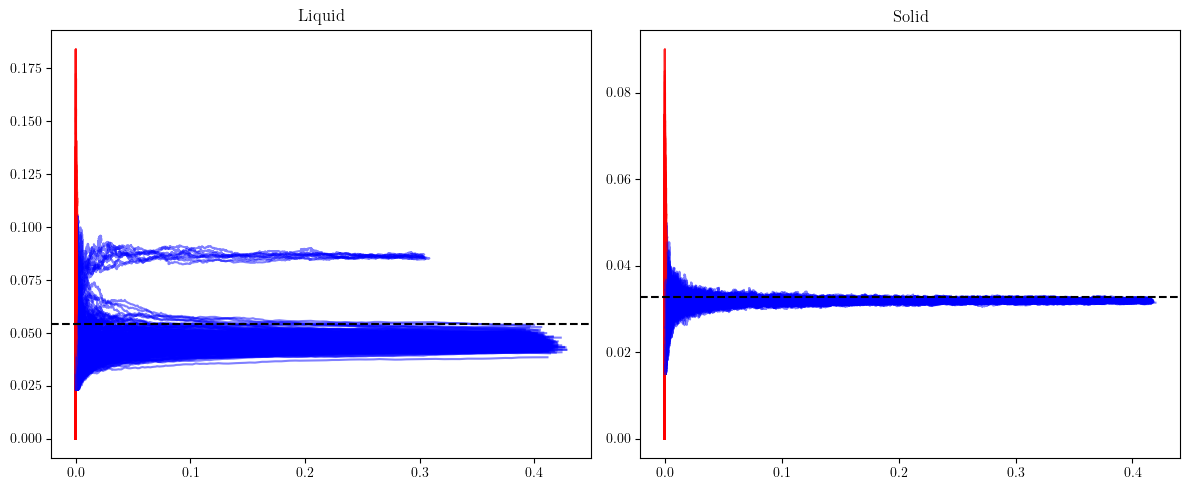

In [8]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

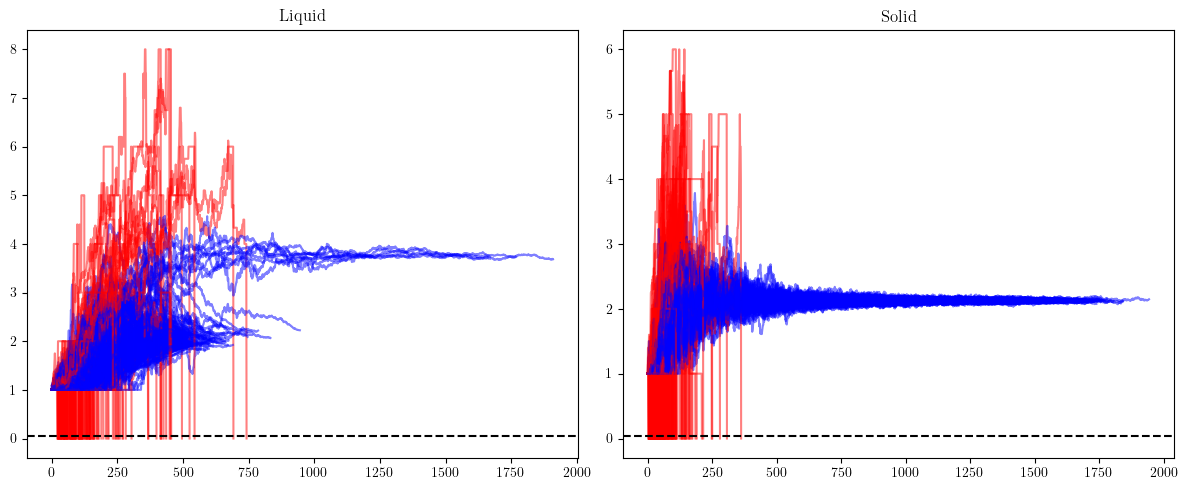

In [9]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

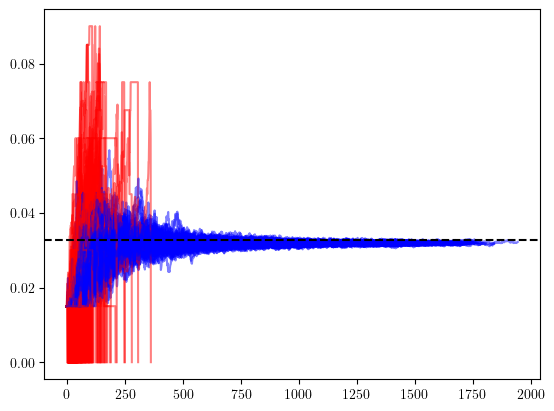

In [10]:
for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

plt.axhline(0.032614, color="k", ls="--")

In [13]:
stab = load_adaptive_stability_results()
stabl = load_adaptive_stability_results_liquid()

In [14]:
stabl

,rmax,stable_dmu,rmax_norm
0,0.214286,0.006175,1.428571
1,0.342857,0.012430,2.285714
2,0.407143,0.014065,2.714286
3,0.407143,0.014502,2.714286
4,0.407143,0.014916,2.714286
...,...,...,...
210,1.036957,0.018487,6.913043
211,1.036957,0.019720,6.913043
212,1.050000,0.017003,7.000000
213,1.050000,0.018377,7.000000


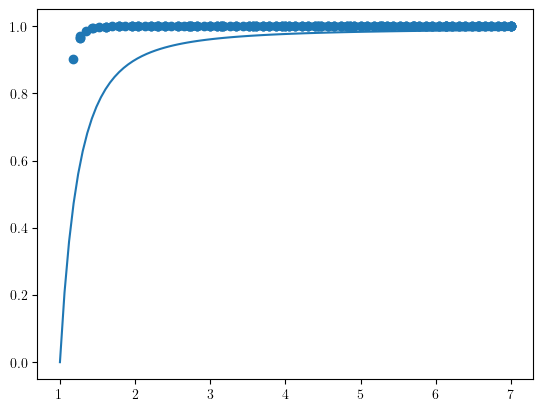

In [ ]:
x = np.linspace(1,7,100)

def th_pred(x):
    mu = 0.015
    ps = (1-mu)**(10)
    return (1-((1+1/x)/2)**(1/10))
def pdeath(x):
    return 1-(1-x)**(10)

plt.plot(x, pdeath(th_pred(x)))
plt.scatter(stabl['rmax_norm'], pdeath(stabl['stable_dmu']*10))